Configuration :
  noise_level: 10.0
  gt_type: vessels
  spacing_mm: 1.0
  block_core: 50
  halo: 10
  caliber_bins_mm: [0, 0.5, 1.0, 1.5, 2.0, 3.0, inf]
  caliber_labels: ['0–0.5 mm', '0.5–1.0 mm', '1.0–1.5 mm', '1.5–2.0 mm', '2.0–3.0 mm', '>3.0 mm']
  vessel_label_name: Vaisseaux (VascuSynth, GT seuillé)
  n_jobs: 1
  data_dir: /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/vascusynth_preprocessed
  output_dir: /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/results/vessel_size_vascusynth

📊 Nombre total de cas trouvés : 30
📌 Tous les cas seront analysés (30)

📋 Cas disponibles :
  Group10_data11 : Group10 Data11 | σ=10.0 | GT=vessels
  Group10_data7 : Group10 Data7 | σ=10.0 | GT=vessels
  Group10_data9 : Group10 Data9 | σ=10.0 | GT=vessels
  Group1_data11 : Group1 Data11 | σ=10.0 | GT=vessels
  Group1_data7 : Group1 Data7 | σ=10.0 | GT=vessels
  ... et 25 autres

📊 Stati

Traitement des cas VascuSynth:   0%|          | 0/30 [00:00<?, ?it/s]


=== STATISTIQUES DE TRAITEMENT ===
Cas traités              : 30
Blocs totaux             : 810
Blocs vides (sans GT)    : 220
Voxels de squelette      : 25,984

Total voxels de squelette analysés : 25,984

                                STATISTIQUES PAR CALIBRE - VASCUSYNTH (en mm)                                 
                          Vaisseau    Calibre  N voxels skel. Rayon moyen (mm) Rayon médian (mm) Intensité moyenne Intensité médiane   Intensité P5–P95 % du vaisseau
Vaisseaux (VascuSynth, GT seuillé)   0–0.5 mm               0                —                 —                 —                 —                  —          0.0%
Vaisseaux (VascuSynth, GT seuillé) 0.5–1.0 mm               0                —                 —                 —                 —                  —          0.0%
Vaisseaux (VascuSynth, GT seuillé) 1.0–1.5 mm           19882    1.120 ± 0.188             1.000   93.135 ± 13.492            94.000 [69.000 ; 114.000]         76.5%
Vaisseaux (VascuS

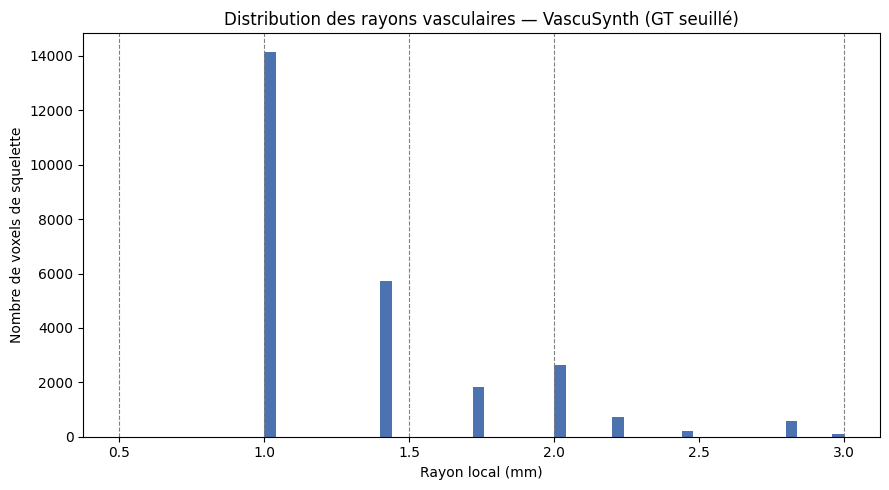

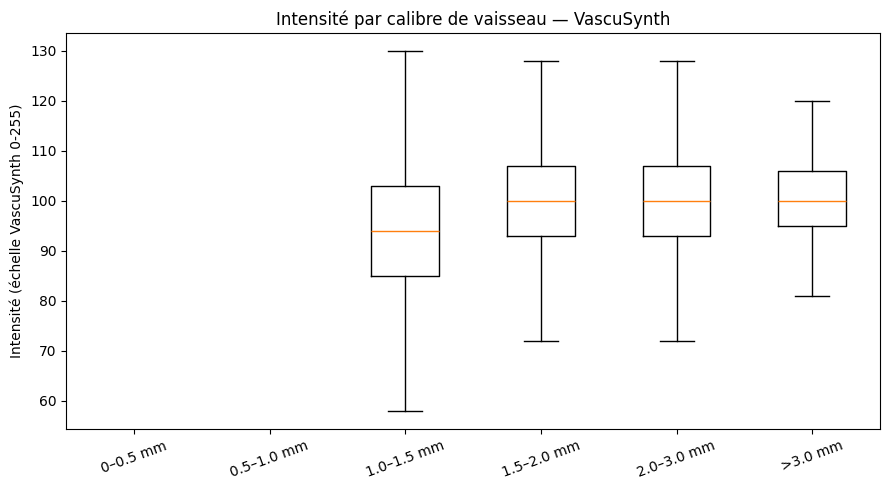

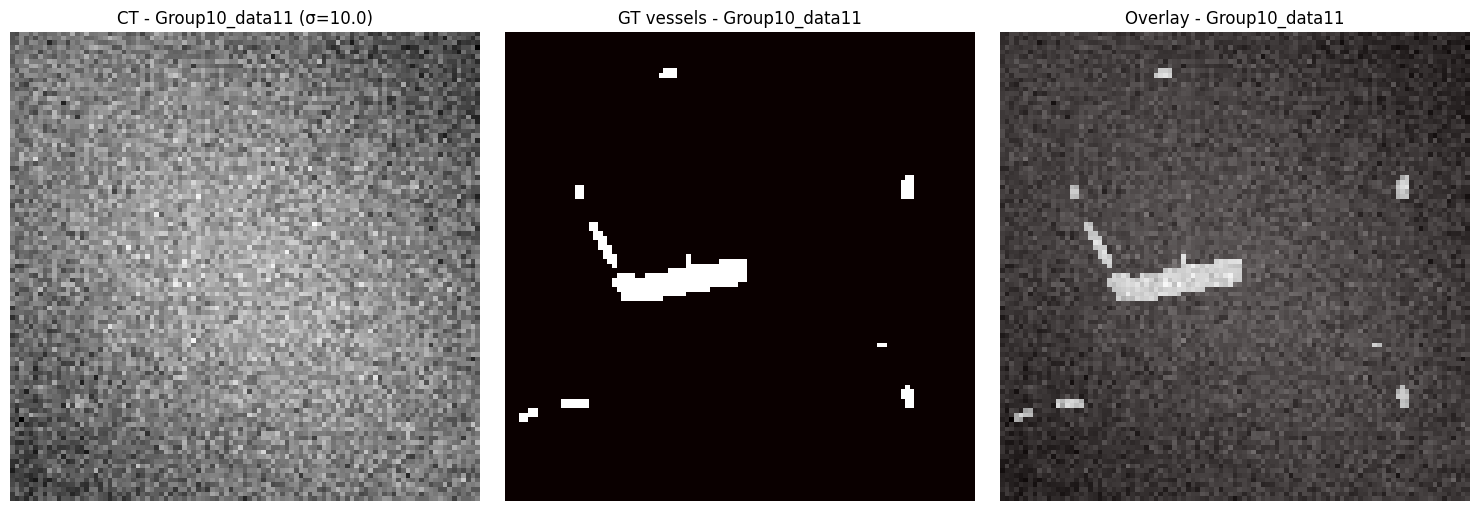

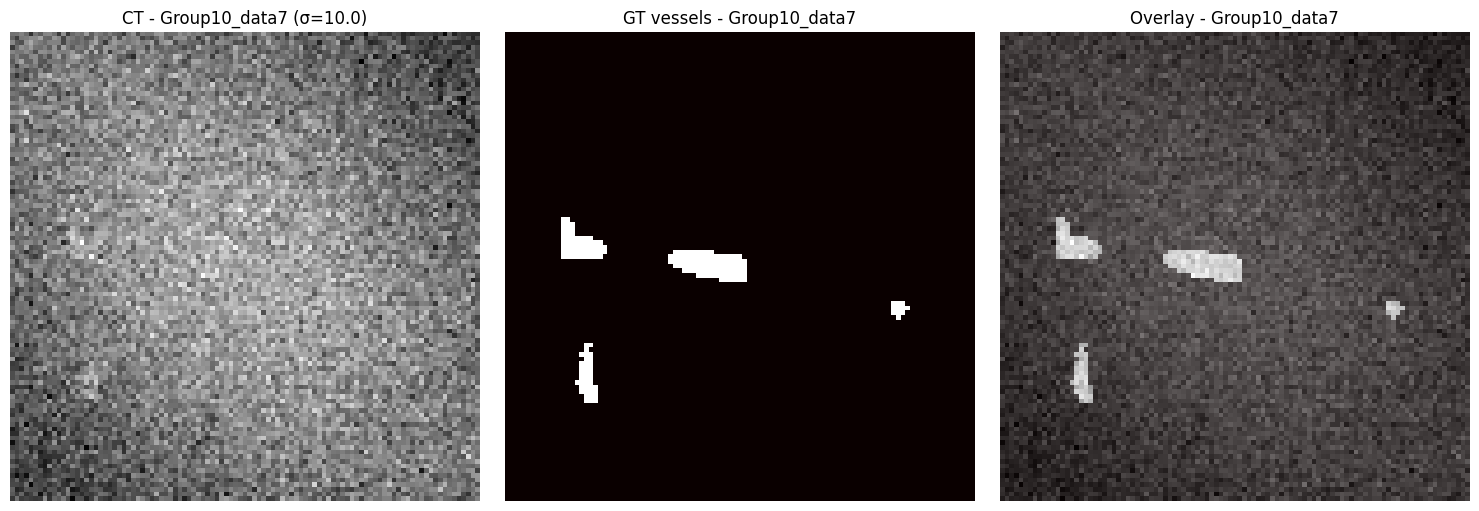

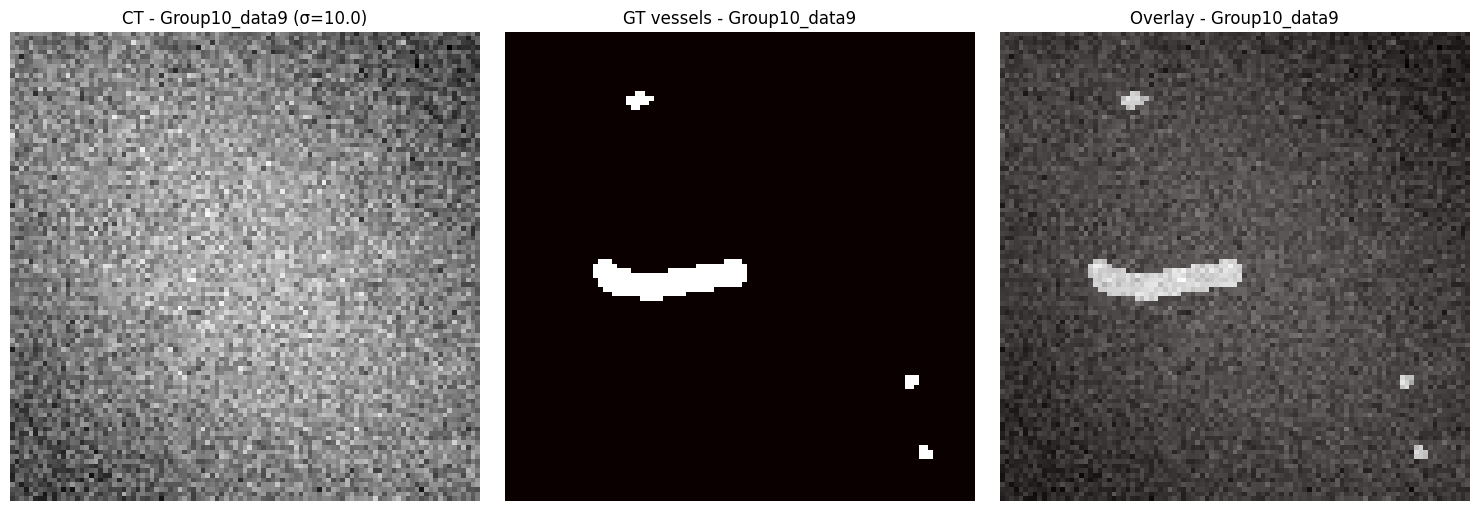

Dropdown(description='Calibre :', options=('0–0.5 mm', '0.5–1.0 mm', '1.0–1.5 mm', '1.5–2.0 mm', '2.0–3.0 mm',…

Output()


STATISTIQUES PAR CAS VASCUSYNTH (en mm)
                n_voxels  radius_mean_mm  radius_std  radius_median_mm  \
case_id                                                                  
Group9_data11       1042           1.298       0.438               1.0   
Group8_data11       1011           1.310       0.442               1.0   
Group1_data11       1010           1.283       0.427               1.0   
Group6_data11       1007           1.299       0.427               1.0   
Group4_data11        993           1.264       0.423               1.0   
Group2_data11        992           1.314       0.470               1.0   
Group10_data11       981           1.295       0.429               1.0   
Group7_data11        968           1.325       0.475               1.0   
Group7_data9         951           1.305       0.458               1.0   
Group3_data11        948           1.281       0.434               1.0   
Group9_data9         931           1.276       0.427               1.0 

In [ ]:
## 1. Imports
import os
import numpy as np
import pandas as pd
import nibabel as nib
from scipy.ndimage import distance_transform_edt
from skimage.morphology import skeletonize
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import glob
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

## 2. Configuration (en mm)
CONFIG = {
    # Chemins vers les données pré-traitées VascuSynth
    "data_dir": "/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/data/vascusynth_preprocessed",
    "output_dir": "/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/results/vessel_size_vascusynth",
    
    # Sélection des cas à analyser (None = tous)
    "case_selection": None,  # ex: ["Group1_data7", "Group1_data9"] ou None pour tous
    
    # Niveau de bruit à utiliser (5.0, 10.0, 20.0)
    "noise_level": 10.0,  # σ = 10.0 par défaut
    
    # Type de GT à utiliser ('vessels', 'bifurcations', 'neighborhood')
    "gt_type": "vessels",  # 'vessels', 'bifurcations', 'neighborhood'
    
    # Géométrie
    "spacing_mm": 1.0,        # VascuSynth : 1 mm (spacing natif)
    
    # Stratégie de blocs (VascuSynth volumes 101x101x101 donc petits)
    "block_core": 50,           # taille du cœur de bloc traité (voxels)
    "halo": 10,                 # marge ajoutée de chaque côté (voxels)
    
    # Calibres en MILLIMÈTRES (adaptés à VascuSynth)
    "caliber_bins_mm":   [0, 0.5, 1.0, 1.5, 2.0, 3.0, np.inf],
    "caliber_labels":    ["0–0.5 mm", "0.5–1.0 mm", "1.0–1.5 mm", "1.5–2.0 mm", "2.0–3.0 mm", ">3.0 mm"],
    "vessel_label_name": "Vaisseaux (VascuSynth, GT seuillé)",
    
    # Parallélisation optionnelle
    "n_jobs": 1,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("Configuration :")
for key, val in CONFIG.items():
    if key not in ["data_dir", "output_dir", "case_selection"]:
        print(f"  {key}: {val}")
print(f"  data_dir: {CONFIG['data_dir']}")
print(f"  output_dir: {CONFIG['output_dir']}")

## 3. Détection automatique des cas VascuSynth (nouvelle structure)

def extract_noise_level(filename):
    """
    Extrait le niveau de bruit du nom de fichier.
    Gère les formats : 'rician_10.0', 'rician_10.0.', 'rician_10', etc.
    """
    # Chercher le pattern rician_ suivi d'un nombre
    match = re.search(r"rician_([\d.]+)", filename)
    if match:
        # Nettoyer la chaîne : enlever les points finaux
        noise_str = match.group(1).rstrip('.')
        try:
            return float(noise_str)
        except ValueError:
            # Si la conversion échoue, essayer de prendre juste les chiffres
            digits = re.search(r"(\d+\.?\d*)", noise_str)
            if digits:
                return float(digits.group(1))
    return None

def find_vascusynth_cases(data_dir, noise_level=10.0, gt_type="vessels"):
    """
    Trouve tous les cas VascuSynth disponibles dans la nouvelle structure.
    
    Structure attendue :
        data_dir/
        ├── images/
        │   └── GroupX_dataY/
        │       ├── GroupX_dataY_rician_5.0.nii.gz
        │       ├── GroupX_dataY_rician_10.0.nii.gz
        │       └── GroupX_dataY_rician_20.0.nii.gz
        └── labels/
            └── GroupX_dataY/
                ├── GroupX_dataY_vessels_gt.nii.gz
                ├── GroupX_dataY_bifurcations_gt.nii.gz
                └── GroupX_dataY_vessel_neighborhood.nii.gz
    """
    data_dir = Path(data_dir)
    images_dir = data_dir / "images"
    labels_dir = data_dir / "labels"
    
    if not images_dir.exists():
        print(f"⚠️ Dossier images introuvable : {images_dir}")
        return []
    
    cases = []
    
    # Parcourir les sous-dossiers dans images/
    for case_dir in sorted(images_dir.iterdir()):
        if not case_dir.is_dir():
            continue
        
        case_id = case_dir.name
        
        # Vérifier que le nom correspond au format GroupX_dataY
        if not re.match(r"Group\d+_data\d+", case_id):
            continue
        
        # Construire le chemin de l'image avec le niveau de bruit sélectionné
        image_path = case_dir / f"{case_id}_rician_{noise_level:.1f}.nii.gz"
        
        # Si l'image n'existe pas, essayer de trouver un autre niveau de bruit
        if not image_path.exists():
            rician_files = list(case_dir.glob(f"{case_id}_rician_*.nii.gz"))
            if rician_files:
                # Prendre le premier disponible
                image_path = rician_files[0]
                # Extraire le niveau de bruit avec la fonction robuste
                actual_noise = extract_noise_level(image_path.name)
                if actual_noise is not None:
                    print(f"  ⚠️ {case_id}: σ={noise_level} non trouvé, utilisation σ={actual_noise}")
                else:
                    print(f"  ⚠️ {case_id}: impossible d'extraire le niveau de bruit de {image_path.name}")
            else:
                continue
        
        # Construire le chemin du GT selon le type
        gt_filename = f"{case_id}_{gt_type}_gt.nii.gz"
        gt_path = labels_dir / case_id / gt_filename
        
        # Fallback : essayer vessels_gt si le type demandé n'existe pas
        if not gt_path.exists() and gt_type != "vessels":
            fallback_path = labels_dir / case_id / f"{case_id}_vessels_gt.nii.gz"
            if fallback_path.exists():
                gt_path = fallback_path
                print(f"  ⚠️ {case_id}: {gt_type}_gt non trouvé, utilisation vessels_gt")
            else:
                continue
        
        if not gt_path.exists():
            continue
        
        # Extraire group et data
        match = re.match(r"Group(\d+)_data(\d+)", case_id)
        if match:
            group = int(match.group(1))
            data = int(match.group(2))
        else:
            group, data = 0, 0
        
        # Extraire le niveau de bruit avec la fonction robuste
        actual_noise = extract_noise_level(image_path.name)
        if actual_noise is None:
            actual_noise = noise_level
        
        # Déterminer le type de GT réel
        actual_gt_type = gt_type if gt_path.name.endswith(f"{gt_type}_gt.nii.gz") else "vessels"
        
        cases.append({
            "case_id": case_id,
            "image_path": str(image_path),
            "gt_path": str(gt_path),
            "group": group,
            "data": data,
            "noise_level": actual_noise,
            "gt_type": actual_gt_type,
        })
    
    return cases

# Détecter les cas
all_cases = find_vascusynth_cases(
    CONFIG["data_dir"], 
    noise_level=CONFIG["noise_level"],
    gt_type=CONFIG["gt_type"]
)

print(f"\n📊 Nombre total de cas trouvés : {len(all_cases)}")

if CONFIG["case_selection"] is not None:
    cases = [c for c in all_cases if c["case_id"] in CONFIG["case_selection"]]
    print(f"📌 Cas sélectionnés : {len(cases)}")
else:
    cases = all_cases
    print(f"📌 Tous les cas seront analysés ({len(cases)})")

# Afficher les premiers cas
print("\n📋 Cas disponibles :")
for c in cases[:5]:
    gt_display = c.get("gt_type", "vessels")
    print(f"  {c['case_id']} : Group{c['group']} Data{c['data']} | σ={c['noise_level']:.1f} | GT={gt_display}")
if len(cases) > 5:
    print(f"  ... et {len(cases)-5} autres")

# Statistiques des cas
if cases:
    groups = sorted(set(c["group"] for c in cases))
    data_indices = sorted(set(c["data"] for c in cases))
    noise_levels = sorted(set(c["noise_level"] for c in cases))
    gt_types = sorted(set(c.get("gt_type", "vessels") for c in cases))
    
    print(f"\n📊 Statistiques des cas :")
    print(f"  Groupes : {groups}")
    print(f"  Data    : {data_indices}")
    print(f"  Bruit   : {noise_levels}")
    print(f"  GT type : {gt_types}")

## 4. Chargement des volumes (premier cas pour test)
if cases:
    test_case = cases[0]
    print(f"\n🧪 Cas test : {test_case['case_id']}")
    print(f"   Image : {test_case['image_path']}")
    print(f"   GT    : {test_case['gt_path']}")
    print(f"   Bruit : σ={test_case['noise_level']:.1f}")
    print(f"   GT type: {test_case.get('gt_type', 'vessels')}")
    
    ct_img = nib.load(test_case["image_path"], mmap=True)
    gt_img = nib.load(test_case["gt_path"], mmap=True)
    
    assert ct_img.shape == gt_img.shape, "Le CT et la GT doivent avoir la même grille"
    shape = ct_img.shape
    
    print(f"\nDimensions du volume : {shape}")
    print(f"Nombre de voxels     : {np.prod(shape):,}")
    print(f"Spacing utilisé      : {CONFIG['spacing_mm']} mm")
    print(f"Dtype CT / GT        : {ct_img.get_data_dtype()} / {gt_img.get_data_dtype()}")

## 5. Détermination de black_ridges pour VascuSynth

def determine_black_ridges_vascusynth(ct_path, gt_path, spacing_mm=1.0, sample_size=None):
    """
    Détermine si les vaisseaux sont plus clairs ou plus sombres que le fond.
    Pour VascuSynth, les vaisseaux sont généralement plus clairs (valeurs ~0-255).
    """
    ct_img = nib.load(ct_path, mmap=True)
    gt_img = nib.load(gt_path, mmap=True)
    
    ct_data = ct_img.get_fdata().astype(np.float32)
    gt_data = gt_img.get_fdata().astype(np.float32)
    
    # Binariser la GT
    gt_binary = (gt_data > 0.5).astype(np.uint8)
    
    # Échantillonner
    if sample_size is not None:
        mask = gt_binary > 0
        vessel_indices = np.where(mask)
        n_vessels = len(vessel_indices[0])
        
        if n_vessels > sample_size:
            idx = np.random.choice(n_vessels, sample_size, replace=False)
            vessel_indices = (vessel_indices[0][idx], vessel_indices[1][idx], vessel_indices[2][idx])
        
        background_mask = ~mask
        bg_indices = np.where(background_mask)
        n_bg = len(bg_indices[0])
        if n_bg > sample_size:
            idx = np.random.choice(n_bg, sample_size, replace=False)
            bg_indices = (bg_indices[0][idx], bg_indices[1][idx], bg_indices[2][idx])
    else:
        vessel_indices = np.where(gt_binary > 0)
        bg_indices = np.where(gt_binary == 0)
    
    vessel_intensities = ct_data[vessel_indices]
    background_intensities = ct_data[bg_indices]
    
    vessel_mean = vessel_intensities.mean()
    bg_mean = background_intensities.mean()
    vessel_median = np.median(vessel_intensities)
    bg_median = np.median(background_intensities)
    
    # VascuSynth : valeurs plus élevées = vaisseaux plus clairs
    black_ridges = vessel_mean > bg_mean
    
    stats = {
        "vessel_mean": vessel_mean,
        "background_mean": bg_mean,
        "vessel_median": vessel_median,
        "background_median": bg_median,
        "difference": vessel_mean - bg_mean,
        "vessel_std": vessel_intensities.std(),
        "background_std": background_intensities.std(),
        "n_vessel_samples": len(vessel_intensities),
        "n_background_samples": len(background_intensities),
        "black_ridges": black_ridges,
    }
    
    return black_ridges, stats

# Analyser quelques cas pour déterminer black_ridges
sample_cases = cases[:5] if len(cases) >= 5 else cases
black_ridges_values = []
for c in sample_cases:
    br, stats = determine_black_ridges_vascusynth(
        c["image_path"], 
        c["gt_path"], 
        spacing_mm=CONFIG["spacing_mm"],
        sample_size=5000
    )
    black_ridges_values.append(br)
    print(f"{c['case_id']}: black_ridges={br}, diff={stats['difference']:.2f}")

# Valeur majoritaire
black_ridges = max(set(black_ridges_values), key=black_ridges_values.count)
print(f"\n✅ black_ridges retenu : {black_ridges}")
print(f"   → {'Vaisseaux PLUS CLAIRS que le fond' if black_ridges else 'Vaisseaux PLUS SOMBRES que le fond'}")

## 6. Fonction de traitement d'un bloc (adaptée VascuSynth)

def process_block_vascusynth(gt_padded, ct_padded, core_in_padded, spacing_mm, black_ridges):
    """
    Traite un bloc VascuSynth.
    Note : VascuSynth a des valeurs d'intensité 0-255 (uchar).
    """
    if not gt_padded.any():
        return np.empty(0), np.empty(0)
    
    edt_mm = distance_transform_edt(gt_padded) * spacing_mm  # ← en mm
    
    # Squelettisation
    skel = skeletonize(gt_padded.astype(bool))
    skel_core = np.zeros_like(skel)
    skel_core[core_in_padded] = skel[core_in_padded]
    
    coords = np.nonzero(skel_core)
    radii_mm = edt_mm[coords]  # ← en mm
    intensities = ct_padded[coords]
    return radii_mm, intensities

## 7. Génération des blocs pour un cas

def generate_blocks_single(shape, core_size, halo):
    """Génère les blocs pour un seul volume (VascuSynth est petit)."""
    for x0 in range(0, shape[0], core_size):
        x1 = min(x0 + core_size, shape[0])
        for y0 in range(0, shape[1], core_size):
            y1 = min(y0 + core_size, shape[1])
            for z0 in range(0, shape[2], core_size):
                z1 = min(z0 + core_size, shape[2])
                
                px0, px1 = max(x0 - halo, 0), min(x1 + halo, shape[0])
                py0, py1 = max(y0 - halo, 0), min(y1 + halo, shape[1])
                pz0, pz1 = max(z0 - halo, 0), min(z1 + halo, shape[2])
                
                padded_slices = (slice(px0, px1), slice(py0, py1), slice(pz0, pz1))
                core_in_padded = (slice(x0 - px0, x1 - px0),
                                  slice(y0 - py0, y1 - py0),
                                  slice(z0 - pz0, z1 - pz0))
                core_in_global = (slice(x0, x1), slice(y0, y1), slice(z0, z1))
                
                yield padded_slices, core_in_padded, core_in_global

## 8. Traitement de tous les cas VascuSynth

all_radii = []
all_intensities = []
all_case_ids = []
all_noise_levels = []
all_gt_types = []
n_empty_blocks = 0
total_blocks = 0

for case in tqdm(cases, desc="Traitement des cas VascuSynth"):
    ct_img = nib.load(case["image_path"], mmap=True)
    gt_img = nib.load(case["gt_path"], mmap=True)
    shape = ct_img.shape
    
    case_radii = []
    case_intensities = []
    
    for padded_slices, core_in_padded, core_in_global in generate_blocks_single(shape, CONFIG["block_core"], CONFIG["halo"]):
        total_blocks += 1
        gt_block = np.asarray(gt_img.dataobj[padded_slices]) > 0.5
        if not gt_block.any():
            n_empty_blocks += 1
            continue
        ct_block = np.asarray(ct_img.dataobj[padded_slices])
        
        r, i = process_block_vascusynth(gt_block, ct_block, core_in_padded, CONFIG["spacing_mm"], black_ridges)
        if r.size:
            case_radii.append(r)
            case_intensities.append(i)
    
    if case_radii:
        all_radii.extend(np.concatenate(case_radii))
        all_intensities.extend(np.concatenate(case_intensities))
        n_voxels = len(np.concatenate(case_radii))
        all_case_ids.extend([case["case_id"]] * n_voxels)
        all_noise_levels.extend([case.get("noise_level", CONFIG["noise_level"])] * n_voxels)
        all_gt_types.extend([case.get("gt_type", CONFIG["gt_type"])] * n_voxels)

# Concaténer tous les résultats
radii_mm = np.array(all_radii) if all_radii else np.empty(0)
intensities = np.array(all_intensities) if all_intensities else np.empty(0)
case_ids = np.array(all_case_ids) if all_case_ids else np.empty(0, dtype=object)
noise_levels = np.array(all_noise_levels) if all_noise_levels else np.empty(0)
gt_types = np.array(all_gt_types) if all_gt_types else np.empty(0, dtype=object)

print(f"\n=== STATISTIQUES DE TRAITEMENT ===")
print(f"Cas traités              : {len(cases)}")
print(f"Blocs totaux             : {total_blocks}")
print(f"Blocs vides (sans GT)    : {n_empty_blocks}")
print(f"Voxels de squelette      : {len(radii_mm):,}")

## 9. Agrégation et classement par calibre (mm)

df = pd.DataFrame({
    "case_id": case_ids,
    "radius_mm": radii_mm,       # ← en mm
    "intensity": intensities,
    "noise_level": noise_levels,
    "gt_type": gt_types,
})

df["calibre"] = pd.cut(
    df["radius_mm"],
    bins=CONFIG["caliber_bins_mm"],
    labels=CONFIG["caliber_labels"],
    right=False,
)

total_n = len(df)
print(f"\nTotal voxels de squelette analysés : {total_n:,}")
df.head()

## 10. Table de statistiques par calibre (en mm)

rows = []
for label in CONFIG["caliber_labels"]:
    sub = df[df["calibre"] == label]
    n = len(sub)
    if n == 0:
        rows.append([CONFIG["vessel_label_name"], label, 0, "—", "—", "—", "—", "—", "0.0%"])
        continue
    
    r_mean, r_std = sub["radius_mm"].mean(), sub["radius_mm"].std()
    r_med = sub["radius_mm"].median()
    i_mean, i_std = sub["intensity"].mean(), sub["intensity"].std()
    i_med = sub["intensity"].median()
    p5, p95 = sub["intensity"].quantile(0.05), sub["intensity"].quantile(0.95)
    pct = 100 * n / total_n if total_n else 0.0
    
    rows.append([
        CONFIG["vessel_label_name"], label, n,
        f"{r_mean:.3f} ± {r_std:.3f}", f"{r_med:.3f}",
        f"{i_mean:.3f} ± {i_std:.3f}", f"{i_med:.3f}",
        f"[{p5:.3f} ; {p95:.3f}]", f"{pct:.1f}%",
    ])

summary = pd.DataFrame(rows, columns=[
    "Vaisseau", "Calibre", "N voxels skel.", "Rayon moyen (mm)", "Rayon médian (mm)",
    "Intensité moyenne", "Intensité médiane", "Intensité P5–P95", "% du vaisseau",
])

print("\n" + "=" * 110)
print("STATISTIQUES PAR CALIBRE - VASCUSYNTH (en mm)".center(110))
print("=" * 110)
print(summary.to_string(index=False))
summary

## 11. Visualisations (en mm)

# Distribution des rayons en mm
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["radius_mm"], bins=50, color="#4C72B0", edgecolor="none")
for edge in CONFIG["caliber_bins_mm"][1:-1]:
    ax.axvline(edge, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Rayon local (mm)")
ax.set_ylabel("Nombre de voxels de squelette")
ax.set_title("Distribution des rayons vasculaires — VascuSynth (GT seuillé)")
plt.tight_layout()
plt.show()

# Intensité par calibre
fig, ax = plt.subplots(figsize=(9, 5))
data_per_bin = [df.loc[df["calibre"] == lbl, "intensity"].dropna().values
                for lbl in CONFIG["caliber_labels"]]
ax.boxplot(data_per_bin, tick_labels=CONFIG["caliber_labels"], showfliers=False)
ax.set_ylabel("Intensité (échelle VascuSynth 0-255)")
ax.set_title("Intensité par calibre de vaisseau — VascuSynth")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 12. Visualisation d'un cas avec overlay

def visualize_vascusynth_case(case_id, slice_idx=None):
    """Visualise un cas VascuSynth avec overlay du masque GT."""
    case = next((c for c in cases if c["case_id"] == case_id), None)
    if case is None:
        print(f"Cas {case_id} non trouvé")
        return
    
    ct_img = nib.load(case["image_path"])
    gt_img = nib.load(case["gt_path"])
    
    ct_data = ct_img.get_fdata()
    gt_data = gt_img.get_fdata()
    
    if slice_idx is None:
        slice_idx = ct_data.shape[2] // 2
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # CT
    axes[0].imshow(ct_data[:, :, slice_idx], cmap='gray')
    gt_type_display = case.get("gt_type", "vessels")
    axes[0].set_title(f"CT - {case_id} (σ={case['noise_level']:.1f})")
    axes[0].axis('off')
    
    # GT
    axes[1].imshow(gt_data[:, :, slice_idx], cmap='hot')
    axes[1].set_title(f"GT {gt_type_display} - {case_id}")
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(ct_data[:, :, slice_idx], cmap='gray')
    axes[2].imshow(gt_data[:, :, slice_idx], cmap='hot', alpha=0.5)
    axes[2].set_title(f"Overlay - {case_id}")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualiser quelques cas
for case in cases[:3]:
    visualize_vascusynth_case(case["case_id"])

## 13. Dashboard interactif (en mm)

bin_selector = widgets.Dropdown(options=CONFIG["caliber_labels"], description="Calibre :")
out = widgets.Output()

def update_dashboard(change=None):
    with out:
        clear_output(wait=True)
        lbl = bin_selector.value
        sub = df[df["calibre"] == lbl]
        pct = 100 * len(sub) / total_n if total_n else 0.0
        print(f"Calibre {lbl} — {len(sub):,} voxels de squelette ({pct:.1f}% du total)")
        if len(sub):
            fig, axes = plt.subplots(1, 2, figsize=(11, 4))
            axes[0].hist(sub["radius_mm"], bins=30, color="#55A868")
            axes[0].set_title("Rayon (mm)")
            axes[0].set_xlabel("mm")
            axes[1].hist(sub["intensity"], bins=30, color="#C44E52")
            axes[1].set_title("Intensité CT")
            plt.tight_layout()
            plt.show()

bin_selector.observe(update_dashboard, names="value")
display(bin_selector, out)
update_dashboard()

## 14. Statistiques par cas (en mm)

print("\n" + "=" * 60)
print("STATISTIQUES PAR CAS VASCUSYNTH (en mm)")
print("=" * 60)

stats_by_case = df.groupby("case_id").agg({
    "radius_mm": ["count", "mean", "std", "median"],
    "intensity": ["mean", "std", "median"],
    "noise_level": ["first"],
    "gt_type": ["first"],
}).round(3)

stats_by_case.columns = ["n_voxels", "radius_mean_mm", "radius_std", "radius_median_mm", 
                         "intensity_mean", "intensity_std", "intensity_median",
                         "noise_level", "gt_type"]
stats_by_case = stats_by_case.sort_values("n_voxels", ascending=False)
print(stats_by_case.head(20))

## 15. Statistiques par niveau de bruit

print("\n" + "=" * 60)
print("STATISTIQUES PAR NIVEAU DE BRUIT")
print("=" * 60)

stats_by_noise = df.groupby("noise_level").agg({
    "radius_mm": ["count", "mean", "std", "median"],
    "intensity": ["mean", "std", "median"],
}).round(3)
stats_by_noise.columns = ["n_voxels", "radius_mean_mm", "radius_std", "radius_median_mm",
                          "intensity_mean", "intensity_std", "intensity_median"]
print(stats_by_noise)

## 16. Sauvegarde des résultats

# Sauvegarder le DataFrame complet
df.to_csv(os.path.join(CONFIG["output_dir"], "vascusynth_vessel_stats_mm.csv"), index=False)
summary.to_csv(os.path.join(CONFIG["output_dir"], "vascusynth_caliber_summary_mm.csv"), index=False)
stats_by_case.to_csv(os.path.join(CONFIG["output_dir"], "vascusynth_per_case_stats_mm.csv"))
stats_by_noise.to_csv(os.path.join(CONFIG["output_dir"], "vascusynth_stats_by_noise.csv"))

# Sauvegarder la liste des cas traités
cases_df = pd.DataFrame(cases)
cases_df.to_csv(os.path.join(CONFIG["output_dir"], "vascusynth_cases_list.csv"), index=False)

print(f"\n Résultats sauvegardés dans : {CONFIG['output_dir']}")
print(f"   - vascusynth_vessel_stats_mm.csv : données complètes (en mm)")
print(f"   - vascusynth_caliber_summary_mm.csv : résumé par calibre (en mm)")
print(f"   - vascusynth_per_case_stats_mm.csv : statistiques par cas (en mm)")
print(f"   - vascusynth_stats_by_noise.csv : statistiques par niveau de bruit")
print(f"   - vascusynth_cases_list.csv : liste des cas traités")

print("\n" + "=" * 60)
print("ANALYSE VASCUSYNTH TERMINÉE (unités : mm)".center(60))
print("=" * 60)

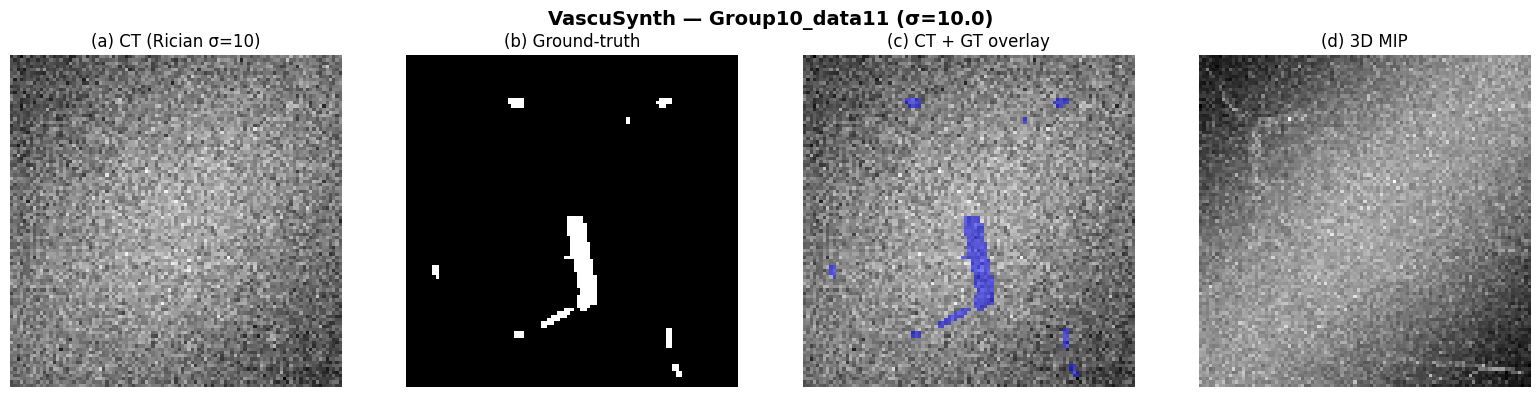

In [5]:
## VascuSynth — Visualisation avec overlay GT

def plot_vascusynth_overlay(case_id: str = None):
    """
    Visualisation VascuSynth avec overlay du GT en bleu.
    """
    if case_id is None:
        case = next((c for c in cases if c.get("noise_level", 0) == 10.0), None)
        if case is None:
            case = cases[0] if cases else None
    else:
        case = next((c for c in cases if c["case_id"] == case_id), None)
    
    if case is None:
        print("Aucun cas VascuSynth trouvé")
        return None
    
    ct_img = nib.load(case["image_path"])
    gt_img = nib.load(case["gt_path"])
    ct_data = ct_img.get_fdata()
    gt_data = gt_img.get_fdata() > 0.5
    
    zc = ct_data.shape[2] // 2
    noise = case.get("noise_level", 10.0)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'VascuSynth — {case["case_id"]} (σ={noise:.1f})', 
                 fontsize=14, fontweight='bold')
    
    # (a) CT
    axes[0].imshow(ct_data[:, :, zc].T, cmap='gray', origin='lower')
    axes[0].set_title('(a) CT (Rician σ=10)')
    axes[0].axis('off')
    
    # (b) GT
    axes[1].imshow(gt_data[:, :, zc].T, cmap='gray', origin='lower')
    axes[1].set_title('(b) Ground-truth')
    axes[1].axis('off')
    
    # (c) Overlay
    axes[2].imshow(ct_data[:, :, zc].T, cmap='gray', origin='lower')
    overlay = np.zeros((*gt_data[:, :, zc].T.shape, 4))
    overlay[gt_data[:, :, zc].T > 0] = [0, 0, 1, 0.5]
    axes[2].imshow(overlay, origin='lower')
    axes[2].set_title('(c) CT + GT overlay')
    axes[2].axis('off')
    
    # (d) MIP 3D
    mip = np.max(ct_data, axis=0)
    axes[3].imshow(mip.T, cmap='gray', origin='lower')
    axes[3].set_title('(d) 3D MIP')
    axes[3].axis('off')
    
    plt.tight_layout()
    return fig

# ── Exécution ──────────────────────────────────────────────────────────────
fig = plot_vascusynth_overlay()
if fig:
    plt.savefig('fig_vascusynth_overlay.png', bbox_inches='tight', dpi=150)
    plt.show()